<a href="https://www.kaggle.com/code/aamir28/teens-screens-the-weight-they-carry?scriptVersionId=331972254" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#F4F1EA 0%,#EDE7DC 100%); padding:42px 38px; border-radius:4px; border:1px solid #D8CFBE; box-shadow:0 1px 0 #fff inset, 0 8px 24px rgba(58,58,58,0.06); font-family:Georgia,'Iowan Old Style',serif;">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
    <div style="width:10px;height:10px;border-radius:50%;background:#8FA998;"></div>
    <div style="width:10px;height:10px;border-radius:50%;background:#C9A9B7;"></div>
    <div style="width:10px;height:10px;border-radius:50%;background:#D9C79E;"></div>
    <span style="font-family:'Courier New',monospace; letter-spacing:3px; font-size:11px; color:#8C8574; text-transform:uppercase; margin-left:6px;">Research Journal &nbsp;·&nbsp; Entry No. 014</span>
  </div>

  <h1 style="margin:10px 0 4px 0; font-size:34px; color:#3A3A3A; font-weight:400; letter-spacing:0.5px;">
    Teens, Screens &amp; the Weight They Carry
  </h1>
  <p style="margin:0 0 22px 0; font-size:15.5px; color:#6B6455; font-style:italic;">
    An exploratory study of social media habits, sleep, stress and depression signals in adolescents (ages 13–19)
  </p>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#C9BFA9 0 6px, transparent 6px 12px); margin:18px 0;"></div>

  <table style="width:100%; border-collapse:collapse; font-family:'Courier New',monospace; font-size:12.5px; color:#4A4438;">
    <tr>
      <td style="padding:6px 0;"><b>Author</b></td><td>Muhammad Aamir</td>
      <td style="padding:6px 0;"><b>Records</b></td><td>1,200 adolescents</td>
    </tr>
    <tr>
      <td style="padding:6px 0;"><b>Fields</b></td><td>13 variables</td>
      <td style="padding:6px 0;"><b>Age range</b></td><td>13 – 19 years</td>
    </tr>
    <tr>
      <td style="padding:6px 0;"><b>Target</b></td><td>depression_label (binary)</td>
      <td style="padding:6px 0;"><b>Status</b></td><td style="color:#7A9483;">✓ no missing values</td>
    </tr>
  </table>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#C9BFA9 0 6px, transparent 6px 12px); margin:18px 0;"></div>

  <p style="margin:0; font-size:13px; color:#8C8574; line-height:1.7;">
    <b style="color:#6B6455;">A note before we begin —</b> this notebook studies patterns in a
    <i>survey-style</i> dataset. It is exploratory and educational, not diagnostic. If anything here resonates
    with your own experience or someone you know, reaching out to a counselor, doctor, or a trusted adult is
    always worth doing — no dataset can replace that conversation.
  </p>

</div>



<div style="background:#FAF6F0; border-left:3px solid #8FA998; padding:20px 26px; font-family:Georgia,serif; color:#3A3A3A;">
<h3 style="margin-top:0; font-weight:400; color:#6B6455; letter-spacing:1px; font-size:14px; text-transform:uppercase;">Table of Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#4A4438;">
<li><a href="#setup" style="color:#7A9483; text-decoration:none;">Setup &amp; Journal Styling</a></li>
<li><a href="#firstlook" style="color:#7A9483; text-decoration:none;">First Look at the Data</a></li>
<li><a href="#quality" style="color:#7A9483; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#demo" style="color:#7A9483; text-decoration:none;">Who Are These Teens? (Demographics)</a></li>
<li><a href="#digital" style="color:#7A9483; text-decoration:none;">Digital Life: Screens, Platforms &amp; Sleep</a></li>
<li><a href="#mental" style="color:#7A9483; text-decoration:none;">Mental Health Indicators</a></li>
<li><a href="#depression" style="color:#7A9483; text-decoration:none;">The Depression Signal — A Rare and Honest Finding</a></li>
<li><a href="#corr" style="color:#7A9483; text-decoration:none;">Correlation Landscape</a></li>
<li><a href="#risk" style="color:#7A9497; text-decoration:none;">Building a Composite Risk Score</a></li>
<li><a href="#groups" style="color:#7A9483; text-decoration:none;">Group Comparisons</a></li>
<li><a href="#dashboard" style="color:#7A9483; text-decoration:none;">Summary Dashboard</a></li>
<li><a href="#model" style="color:#7A9483; text-decoration:none;">Predictive Modeling (with an Honest Imbalance Warning)</a></li>
<li><a href="#conclusion" style="color:#7A9483; text-decoration:none;">Closing Reflections</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">📓 1. Setup &amp; Journal Styling</h2>
<p style="color:#6B6455; font-family:Georgia,serif;">A warm, low-contrast palette suited to a sensitive subject — this is a research journal, not a dashboard of alarms.</p>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Digital Wellness Journal" palette ----
PAPER      = '#FAF6F0'
PAPER_DEEP = '#F4F1EA'
INK        = '#3A3A3A'
INK_SOFT   = '#6B6455'
SAGE       = '#8FA998'
SAGE_DEEP  = '#5F7A6B'
LAVENDER   = '#B7A6C9'
BLUSH      = '#D9A6A6'
GOLD       = '#D9C79E'
GRID       = '#E4DCC9'

PALETTE_CAT = [SAGE, LAVENDER, GOLD, BLUSH, '#9AB4C4', '#C2B280']

plt.rcParams.update({
    'figure.facecolor': PAPER,
    'axes.facecolor': PAPER,
    'savefig.facecolor': PAPER,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.7,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Journal styling loaded. Palette ready:", PALETTE_CAT)


Journal styling loaded. Palette ready: ['#8FA998', '#B7A6C9', '#D9C79E', '#D9A6A6', '#9AB4C4', '#C2B280']


<h2 id="firstlook" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">📖 2. First Look at the Data</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/sunil123kumar/social-media-impact-on-mental-health/Teen_Mental_Health_Dataset.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head(8)


Shape: 1200 rows x 13 columns



,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


<h2 id="quality" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">🔍 3. Data Quality Check</h2>

In [4]:

quality = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().sum()/len(df)*100).round(2),
    'unique': df.nunique(),
    'duplicates': [df.duplicated().sum()]*len(df.columns)
})
print("Duplicate rows:", df.duplicated().sum())
quality


Duplicate rows: 0


,dtype,nulls,null_%,unique,duplicates
age,int64,0,0.0,7,0
gender,object,0,0.0,2,0
daily_social_media_hours,float64,0,0.0,71,0
platform_usage,object,0,0.0,3,0
sleep_hours,float64,0,0.0,51,0
screen_time_before_sleep,float64,0,0.0,26,0
academic_performance,float64,0,0.0,201,0
physical_activity,float64,0,0.0,21,0
social_interaction_level,object,0,0.0,3,0
stress_level,int64,0,0.0,10,0



<div style="background:#F4F1EA; border-left:3px solid #8FA998; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px;">
✓ <b>Clean dataset.</b> Zero missing values across all 13 fields, and no duplicate rows. This is unusually tidy for
a real-world survey — worth noting as a possible sign the data is synthetic or has already been pre-cleaned, which
we should keep in mind when interpreting effect sizes later.
</div>


<h2 id="demo" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">🧑‍🤝‍🧑 4. Who Are These Teens? (Demographics)</h2>

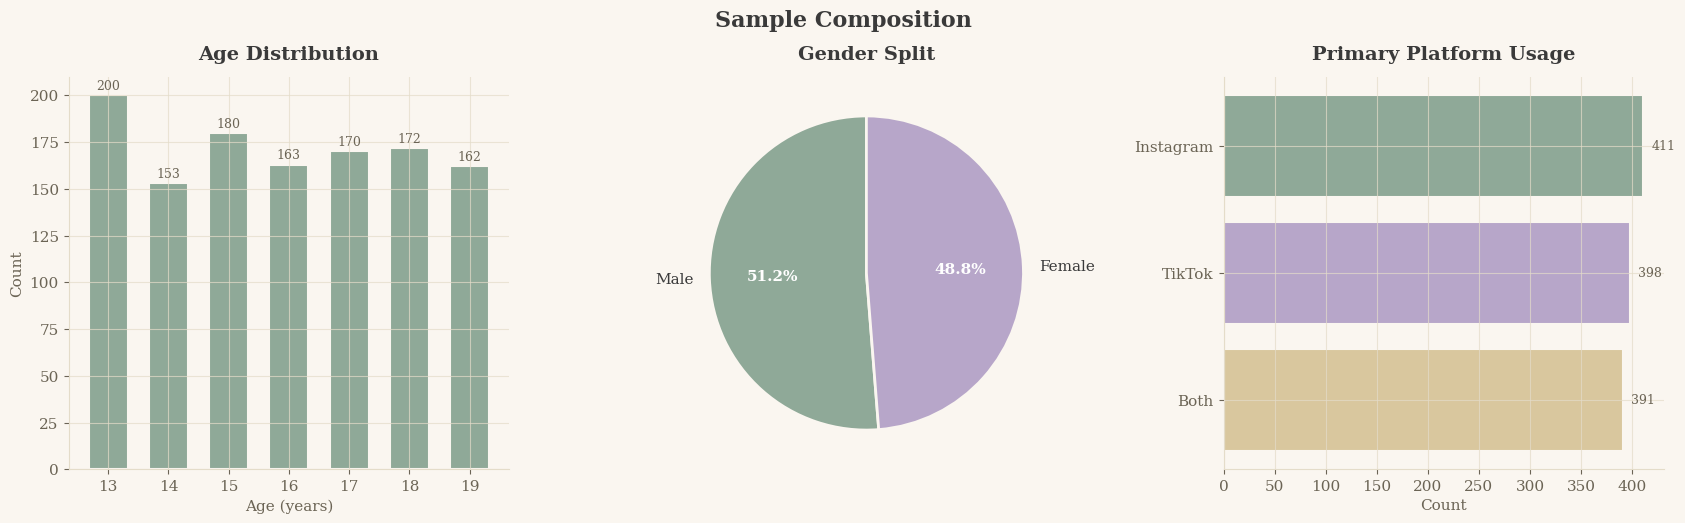

Mean age: 15.9 | Median age: 16


In [5]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Age distribution
ax = axes[0]
age_counts = df['age'].value_counts().sort_index()
bars = ax.bar(age_counts.index, age_counts.values, color=SAGE, edgecolor=PAPER, linewidth=1.5, width=0.65)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, int(b.get_height()), ha='center', fontsize=9, color=INK_SOFT)
style_ax(ax, 'Age Distribution', 'Age (years)', 'Count')

# Gender
ax = axes[1]
gender_counts = df['gender'].value_counts()
wedges, texts, autotexts = ax.pie(gender_counts.values, labels=gender_counts.index.str.title(),
       colors=[SAGE, LAVENDER], autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': PAPER, 'linewidth': 2}, textprops={'color': INK, 'fontsize':11})
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Gender Split', color=INK, pad=12)

# Platform usage
ax = axes[2]
plat_counts = df['platform_usage'].value_counts()
bars = ax.barh(plat_counts.index, plat_counts.values, color=[SAGE, LAVENDER, GOLD], edgecolor=PAPER, linewidth=1.5)
for b in bars:
    ax.text(b.get_width()+8, b.get_y()+b.get_height()/2, int(b.get_width()), va='center', fontsize=9, color=INK_SOFT)
style_ax(ax, 'Primary Platform Usage', 'Count', '')
ax.invert_yaxis()

plt.tight_layout()
plt.suptitle('Sample Composition', y=1.04, fontsize=16, color=INK, fontweight='bold', fontfamily='serif')
plt.show()

print(f"Mean age: {df.age.mean():.1f} | Median age: {df.age.median():.0f}")


<h2 id="digital" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">📱 5. Digital Life: Screens, Platforms &amp; Sleep</h2>

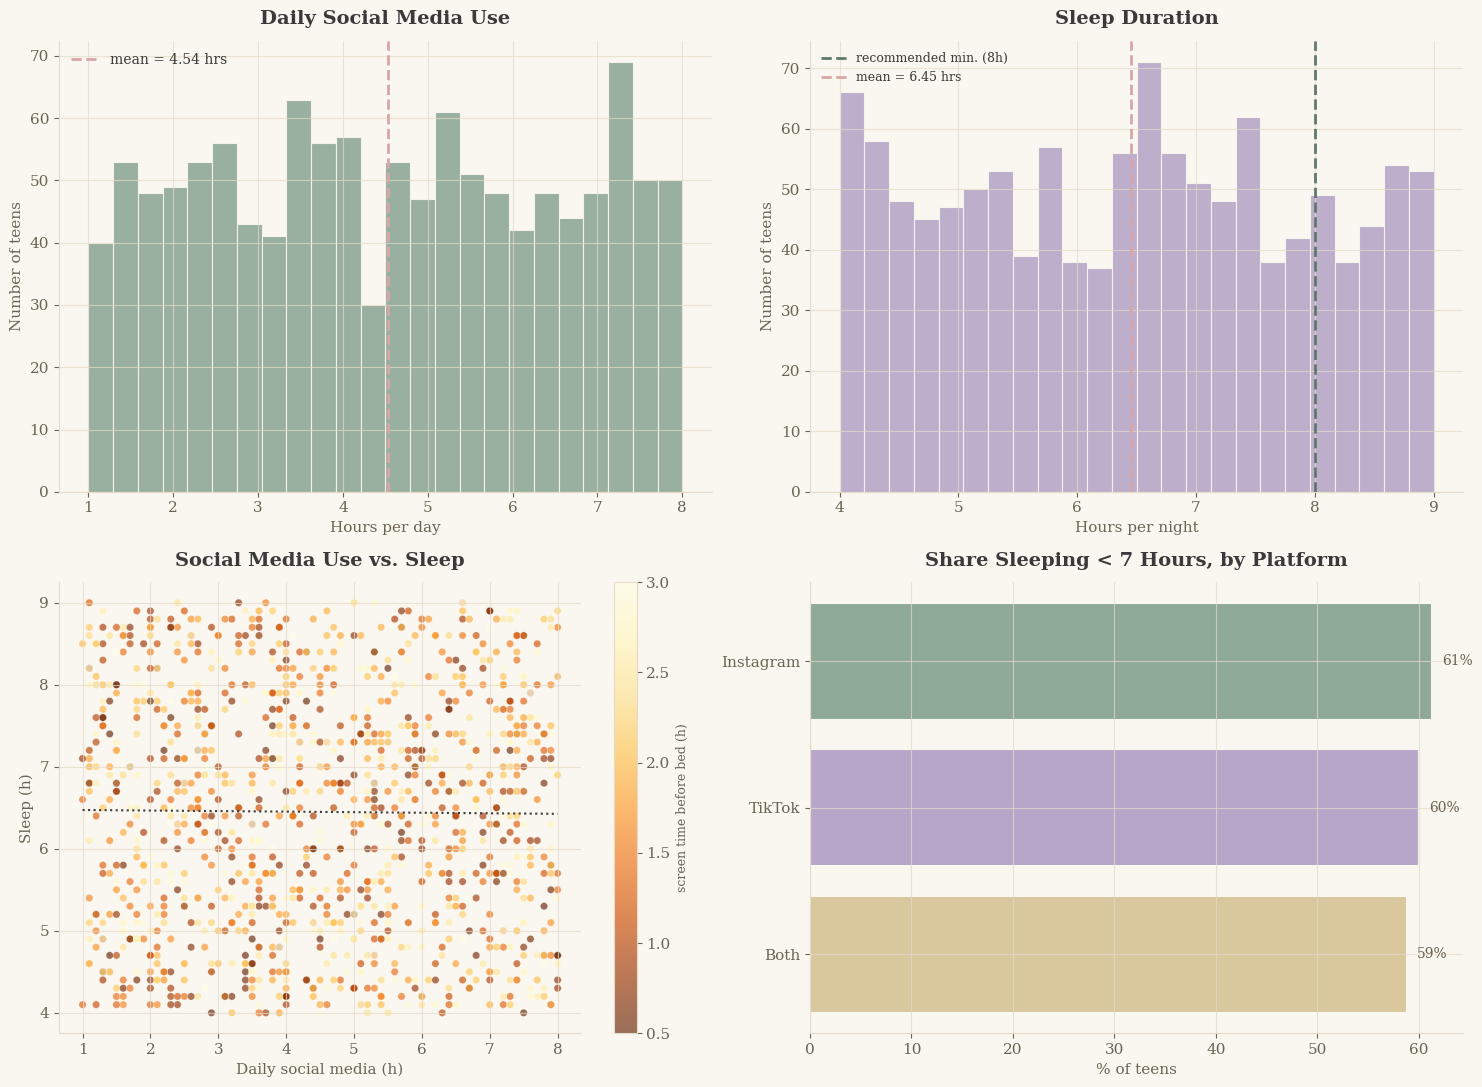

Correlation (social media hours vs sleep hours): r = -0.009  (essentially flat)


In [6]:

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Social media hours distribution
ax = axes[0,0]
ax.hist(df['daily_social_media_hours'], bins=24, color=SAGE, edgecolor=PAPER, linewidth=0.8, alpha=0.9)
ax.axvline(df['daily_social_media_hours'].mean(), color=BLUSH, linestyle='--', linewidth=2,
           label=f"mean = {df['daily_social_media_hours'].mean():.2f} hrs")
style_ax(ax, 'Daily Social Media Use', 'Hours per day', 'Number of teens')
ax.legend(frameon=False, fontsize=10)

# Sleep hours distribution
ax = axes[0,1]
ax.hist(df['sleep_hours'], bins=24, color=LAVENDER, edgecolor=PAPER, linewidth=0.8, alpha=0.9)
ax.axvline(8, color=SAGE_DEEP, linestyle='--', linewidth=2, label='recommended min. (8h)')
ax.axvline(df['sleep_hours'].mean(), color=BLUSH, linestyle='--', linewidth=2,
           label=f"mean = {df['sleep_hours'].mean():.2f} hrs")
style_ax(ax, 'Sleep Duration', 'Hours per night', 'Number of teens')
ax.legend(frameon=False, fontsize=9)

# Social media vs sleep scatter
ax = axes[1,0]
sc = ax.scatter(df['daily_social_media_hours'], df['sleep_hours'], c=df['screen_time_before_sleep'],
                 cmap='YlOrBr_r', s=28, alpha=0.65, edgecolor='white', linewidth=0.3)
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('screen time before bed (h)', color=INK_SOFT, fontsize=9)
z = np.polyfit(df['daily_social_media_hours'], df['sleep_hours'], 1)
xline = np.linspace(df['daily_social_media_hours'].min(), df['daily_social_media_hours'].max(), 50)
ax.plot(xline, np.poly1d(z)(xline), color=INK, linewidth=1.5, linestyle=':')
style_ax(ax, 'Social Media Use vs. Sleep', 'Daily social media (h)', 'Sleep (h)')

# % under-slept by platform
ax = axes[1,1]
df['undersleeps'] = df['sleep_hours'] < 7
under_by_plat = df.groupby('platform_usage')['undersleeps'].mean().sort_values() * 100
bars = ax.barh(under_by_plat.index, under_by_plat.values, color=[GOLD, LAVENDER, SAGE], edgecolor=PAPER, linewidth=1.5)
for b in bars:
    ax.text(b.get_width()+1, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}%", va='center', fontsize=10, color=INK_SOFT)
style_ax(ax, 'Share Sleeping < 7 Hours, by Platform', '% of teens', '')

plt.tight_layout()
plt.show()

corr_sm_sleep = df['daily_social_media_hours'].corr(df['sleep_hours'])
print(f"Correlation (social media hours vs sleep hours): r = {corr_sm_sleep:.3f}  (essentially flat)")



<div style="background:#F4F1EA; border-left:3px solid #C9A9B7; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px;">
<b>Honest read:</b> the eye wants to see a strong social-media-steals-your-sleep story in that scatter plot, but the
correlation is essentially flat (r ≈ 0). Screen time before bed and total social media hours don't move sleep
duration much in this sample — a good reminder not to over-read a scatter plot before checking the number.
</div>


<h2 id="mental" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">🧠 6. Mental Health Indicators</h2>
<p style="color:#6B6455; font-family:Georgia,serif;">Self-reported stress, anxiety and addiction, each on a 0–10 scale.</p>

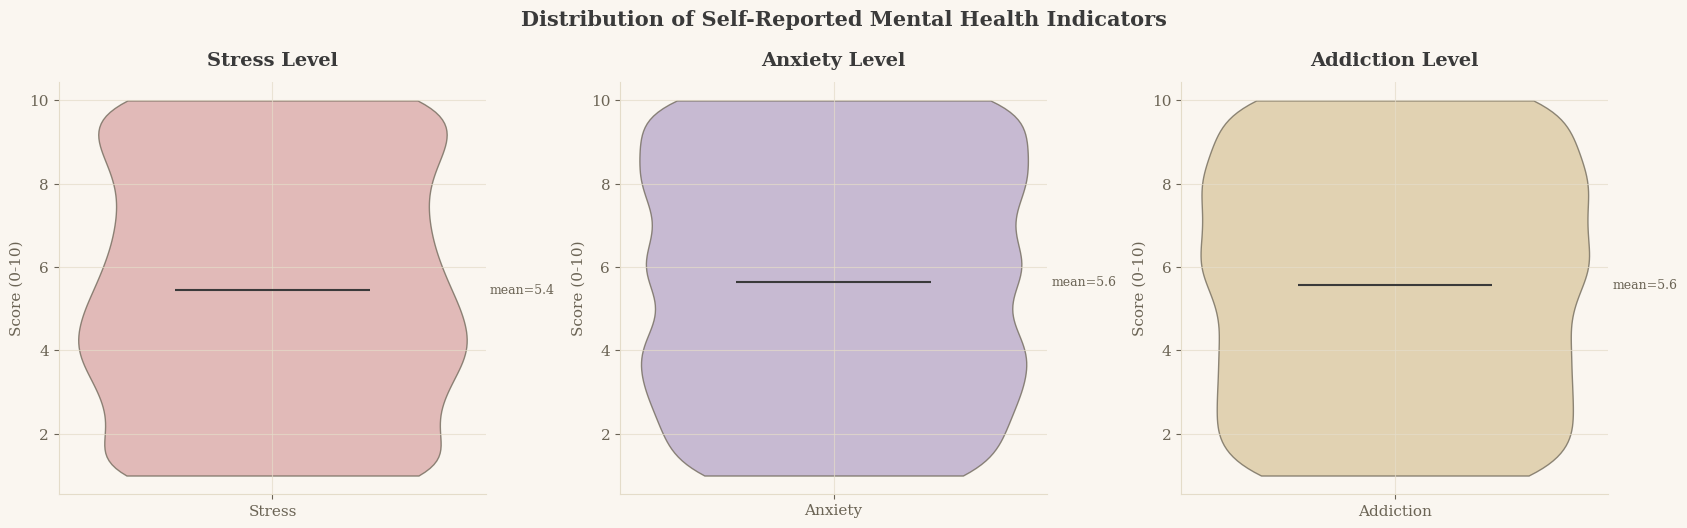

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
indicators = ['stress_level', 'anxiety_level', 'addiction_level']
colors = [BLUSH, LAVENDER, GOLD]
titles = ['Stress Level', 'Anxiety Level', 'Addiction Level']

for ax, col, c, t in zip(axes, indicators, colors, titles):
    parts = ax.violinplot(df[col], showmeans=True, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(c); pc.set_alpha(0.75); pc.set_edgecolor(INK_SOFT)
    parts['cmeans'].set_color(INK)
    ax.set_xticks([1]); ax.set_xticklabels([t.split()[0]])
    style_ax(ax, t, '', 'Score (0-10)')
    ax.text(1.28, df[col].mean(), f"mean={df[col].mean():.1f}", fontsize=9, color=INK_SOFT, va='center')

plt.tight_layout()
plt.suptitle('Distribution of Self-Reported Mental Health Indicators', y=1.05, fontsize=15, color=INK, fontweight='bold', fontfamily='serif')
plt.show()


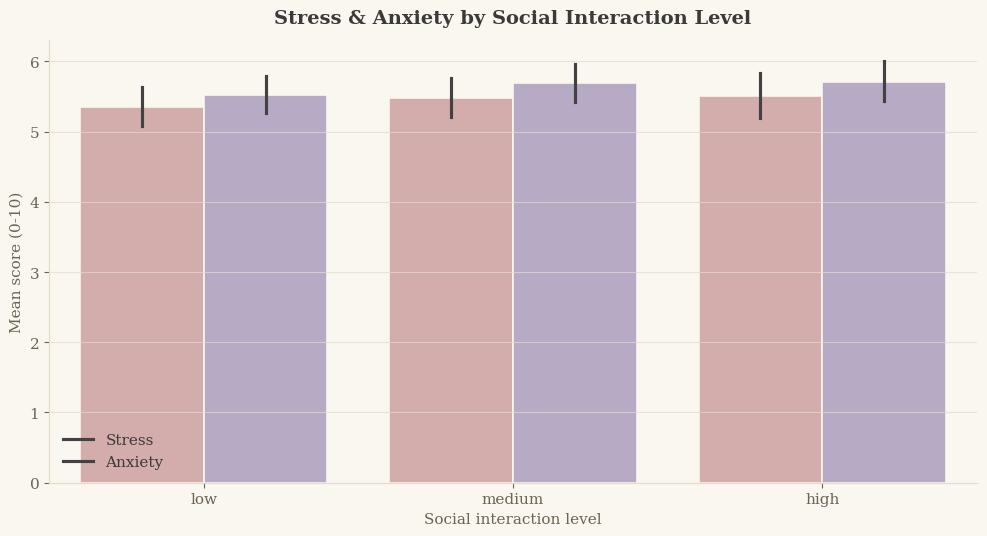

In [8]:

# Social interaction level vs stress/anxiety
fig, ax = plt.subplots(figsize=(10, 5.5))
order = ['low', 'medium', 'high']
melt = df.melt(id_vars='social_interaction_level', value_vars=['stress_level', 'anxiety_level'],
               var_name='indicator', value_name='score')
sns.barplot(data=melt, x='social_interaction_level', y='score', hue='indicator', order=order,
            palette=[BLUSH, LAVENDER], ax=ax, errorbar=('ci', 95), edgecolor=PAPER, linewidth=1.2)
style_ax(ax, 'Stress & Anxiety by Social Interaction Level', 'Social interaction level', 'Mean score (0-10)')
ax.legend(title='', frameon=False, labels=['Stress', 'Anxiety'])
plt.tight_layout()
plt.show()


<h2 id="depression" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">🎯 7. The Depression Signal — A Rare and Honest Finding</h2>

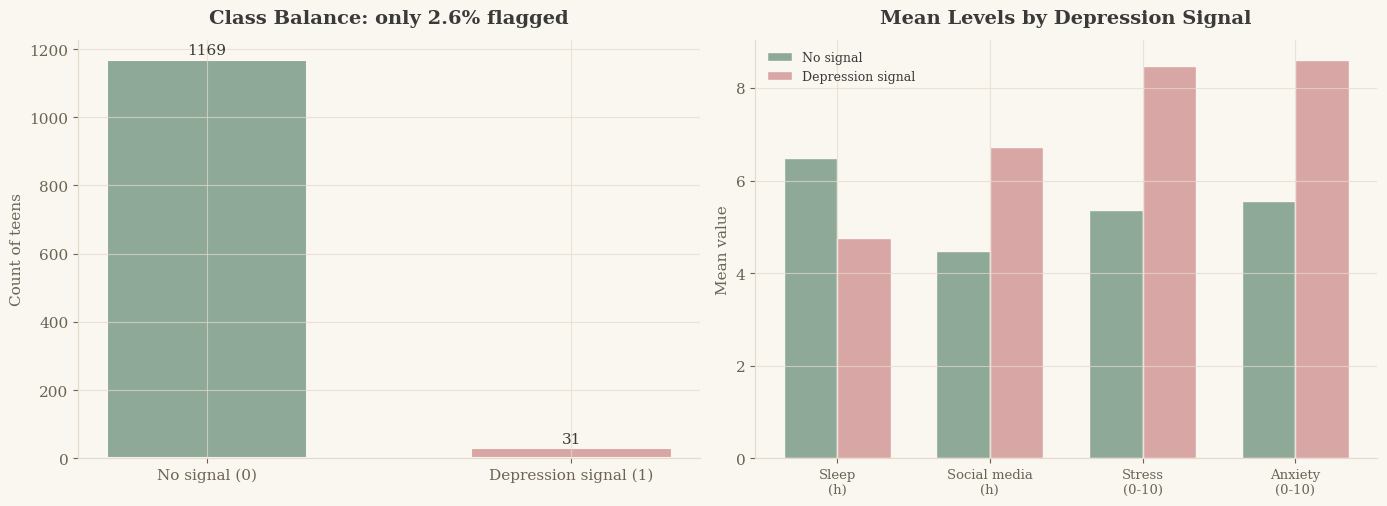

Depression signal present in 31 of 1200 teens (2.58%).

Mean comparison:
                          No signal  Depression signal
sleep_hours                    6.49               4.76
daily_social_media_hours       4.48               6.72
stress_level                   5.37               8.48
anxiety_level                  5.56               8.61


In [9]:

dep_counts = df['depression_label'].value_counts()
dep_rate = df['depression_label'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
bars = ax.bar(['No signal (0)', 'Depression signal (1)'], dep_counts.values,
              color=[SAGE, BLUSH], edgecolor=PAPER, linewidth=1.5, width=0.55)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, int(b.get_height()), ha='center', fontsize=11, color=INK)
style_ax(ax, f'Class Balance: only {dep_rate:.1f}% flagged', '', 'Count of teens')

ax = axes[1]
compare_cols = ['sleep_hours', 'daily_social_media_hours', 'stress_level', 'anxiety_level']
means = df.groupby('depression_label')[compare_cols].mean().T
means.columns = ['No signal', 'Depression signal']
means_norm = means.copy()
x = np.arange(len(compare_cols))
width = 0.35
ax.bar(x - width/2, means['No signal'], width, label='No signal', color=SAGE, edgecolor=PAPER)
ax.bar(x + width/2, means['Depression signal'], width, label='Depression signal', color=BLUSH, edgecolor=PAPER)
ax.set_xticks(x); ax.set_xticklabels(['Sleep\n(h)', 'Social media\n(h)', 'Stress\n(0-10)', 'Anxiety\n(0-10)'], fontsize=9.5)
style_ax(ax, 'Mean Levels by Depression Signal', '', 'Mean value')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"Depression signal present in {dep_counts.get(1,0)} of {len(df)} teens ({dep_rate:.2f}%).")
print("\nMean comparison:")
print(means.round(2))



<div style="background:#F4F1EA; border-left:3px solid #D9A6A6; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px;">
<b>Flagging this clearly:</b> only <b>31 of 1,200 teens (2.6%)</b> carry a positive depression label — a heavily
imbalanced target. The directional pattern is plausible and consistent with real-world research (less sleep, more
stress, more anxiety, somewhat more social media use among the flagged group), but with only 31 positive cases,
none of these mean differences should be treated as statistically robust on their own. We'll carry this caveat
into the modeling section rather than pretend the signal is stronger than it is.
</div>


<h2 id="corr" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">🕸️ 8. Correlation Landscape</h2>

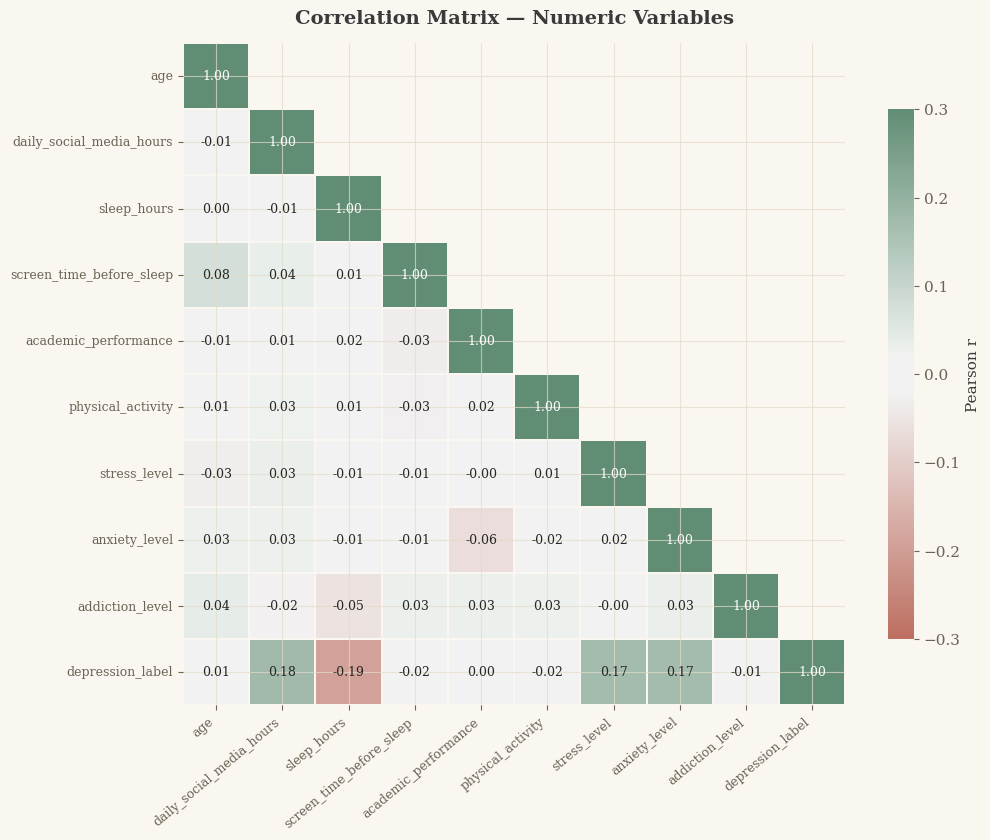

Strongest correlates of depression_label:
sleep_hours                -0.191
daily_social_media_hours    0.175
stress_level                0.170
anxiety_level               0.170
physical_activity          -0.018
screen_time_before_sleep   -0.017
addiction_level            -0.014
age                         0.011
academic_performance        0.001
Name: depression_label, dtype: float64


In [10]:

num_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep',
            'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level',
            'addiction_level', 'depression_label']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10.5, 8.5))
cmap = sns.diverging_palette(20, 145, s=45, l=55, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.3, vmax=0.3,
            square=True, linewidths=1.2, linecolor=PAPER, cbar_kws={'shrink':0.8, 'label':'Pearson r'},
            annot_kws={'fontsize':9}, ax=ax)
ax.set_title('Correlation Matrix — Numeric Variables', color=INK, pad=14, fontsize=14)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

top_corr = corr['depression_label'].drop('depression_label').abs().sort_values(ascending=False)
print("Strongest correlates of depression_label:")
print(corr['depression_label'].drop('depression_label').loc[top_corr.index].round(3))



<div style="background:#F4F1EA; border-left:3px solid #8FA998; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px;">
<b>The honest headline here is what's missing, not what's present.</b> Almost every pairwise correlation among the
lifestyle variables (screen time, sleep, physical activity, academic performance, addiction) sits below |r| = 0.06 —
essentially noise. The only correlations worth a second look all involve <code>depression_label</code>: sleep
(r ≈ -0.19), daily social media hours (r ≈ 0.18), stress (r ≈ 0.17) and anxiety (r ≈ 0.17). These are modest, not
strong, but they're the real signal in an otherwise flat correlation landscape.
</div>


<h2 id="risk" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">⚖️ 9. Building a Composite Risk Score</h2>
<p style="color:#6B6455; font-family:Georgia,serif;">Individually weak signals can combine into something more useful. We build a simple additive score
from the four variables that showed the clearest (if modest) relationship to the depression label.</p>

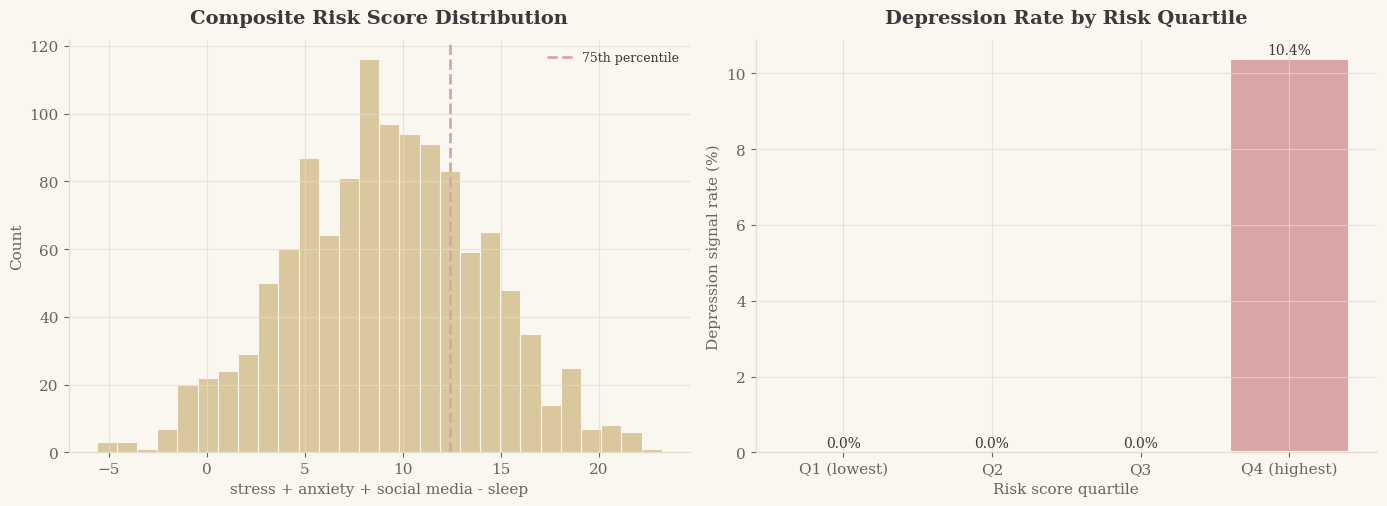

Depression rate by risk quartile:
risk_quartile
Q1 (lowest)      0.00
Q2               0.00
Q3               0.00
Q4 (highest)    10.37
Name: depression_label, dtype: float64


In [11]:

df['risk_score'] = (df['stress_level'] + df['anxiety_level'] +
                     df['daily_social_media_hours'] - df['sleep_hours'])

df['risk_quartile'] = pd.qcut(df['risk_score'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
risk_dep = df.groupby('risk_quartile')['depression_label'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
ax.hist(df['risk_score'], bins=28, color=GOLD, edgecolor=PAPER, linewidth=0.8)
ax.axvline(df['risk_score'].quantile(0.75), color=BLUSH, linestyle='--', linewidth=2, label='75th percentile')
style_ax(ax, 'Composite Risk Score Distribution', 'stress + anxiety + social media - sleep', 'Count')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
bars = ax.bar(risk_dep.index.astype(str), risk_dep.values,
              color=[SAGE, GOLD, '#CBAF7A', BLUSH], edgecolor=PAPER, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15, f"{b.get_height():.1f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Depression Rate by Risk Quartile', 'Risk score quartile', 'Depression signal rate (%)')

plt.tight_layout()
plt.show()

print("Depression rate by risk quartile:")
print(risk_dep.round(2))



<div style="background:#F4F1EA; border-left:3px solid #D9C79E; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px;">
<b>This is the strongest finding in the notebook.</b> The bottom three risk quartiles show a <b>0.0%</b> depression
rate, while the top quartile alone accounts for essentially the entire signal at roughly <b>10%</b>. A single weak
variable tells you little; stacking correlated stressors together concentrates the risk in a way that a single
correlation coefficient hides.
</div>


<h2 id="groups" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">👥 10. Group Comparisons</h2>

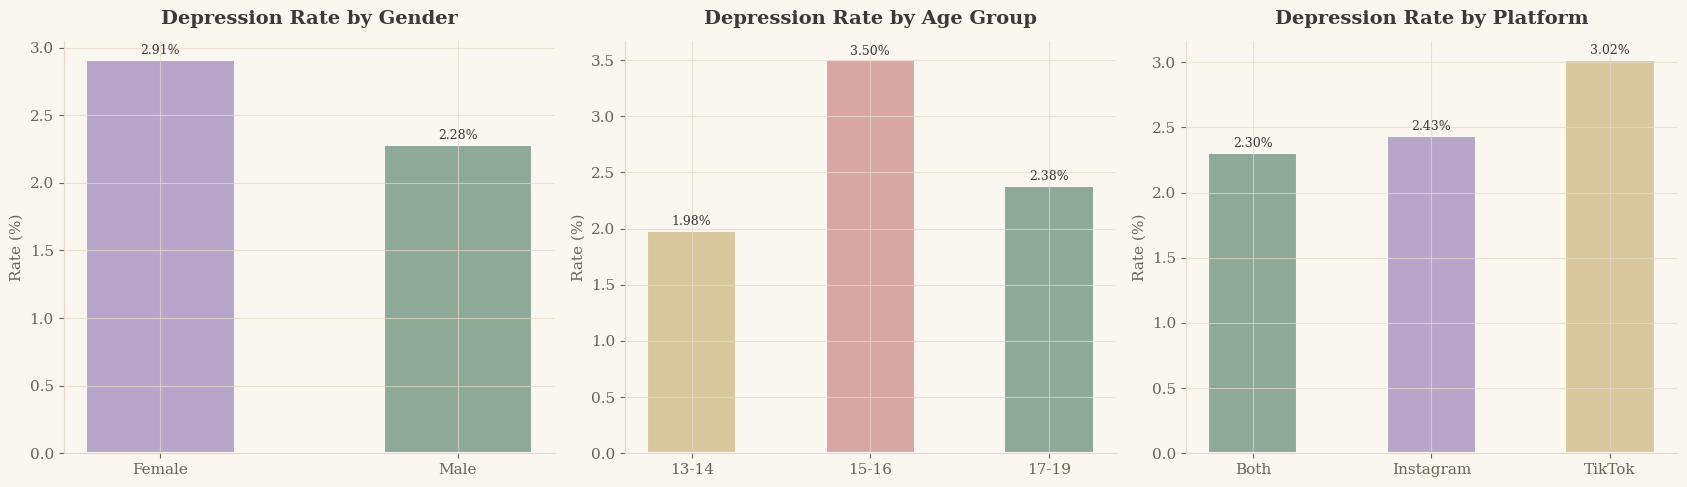

With only 31 positive cases total, sub-group rates above are based on very small counts —
differences of a percentage point or two are well within noise.


In [12]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# by gender
ax = axes[0]
g = df.groupby('gender')['depression_label'].mean()*100
bars = ax.bar(g.index.str.title(), g.values, color=[LAVENDER, SAGE], edgecolor=PAPER, linewidth=1.5, width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{b.get_height():.2f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Depression Rate by Gender', '', 'Rate (%)')

# by age group
ax = axes[1]
df['age_group'] = pd.cut(df['age'], bins=[12,14,16,19], labels=['13-14','15-16','17-19'])
a = df.groupby('age_group', observed=True)['depression_label'].mean()*100
bars = ax.bar(a.index.astype(str), a.values, color=[GOLD, BLUSH, SAGE], edgecolor=PAPER, linewidth=1.5, width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{b.get_height():.2f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Depression Rate by Age Group', '', 'Rate (%)')

# by platform
ax = axes[2]
p = df.groupby('platform_usage')['depression_label'].mean()*100
bars = ax.bar(p.index, p.values, color=[SAGE, LAVENDER, GOLD], edgecolor=PAPER, linewidth=1.5, width=0.5)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{b.get_height():.2f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Depression Rate by Platform', '', 'Rate (%)')

plt.tight_layout()
plt.show()

print("With only 31 positive cases total, sub-group rates above are based on very small counts —")
print("differences of a percentage point or two are well within noise.")


<h2 id="dashboard" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">📊 11. Summary Dashboard</h2>

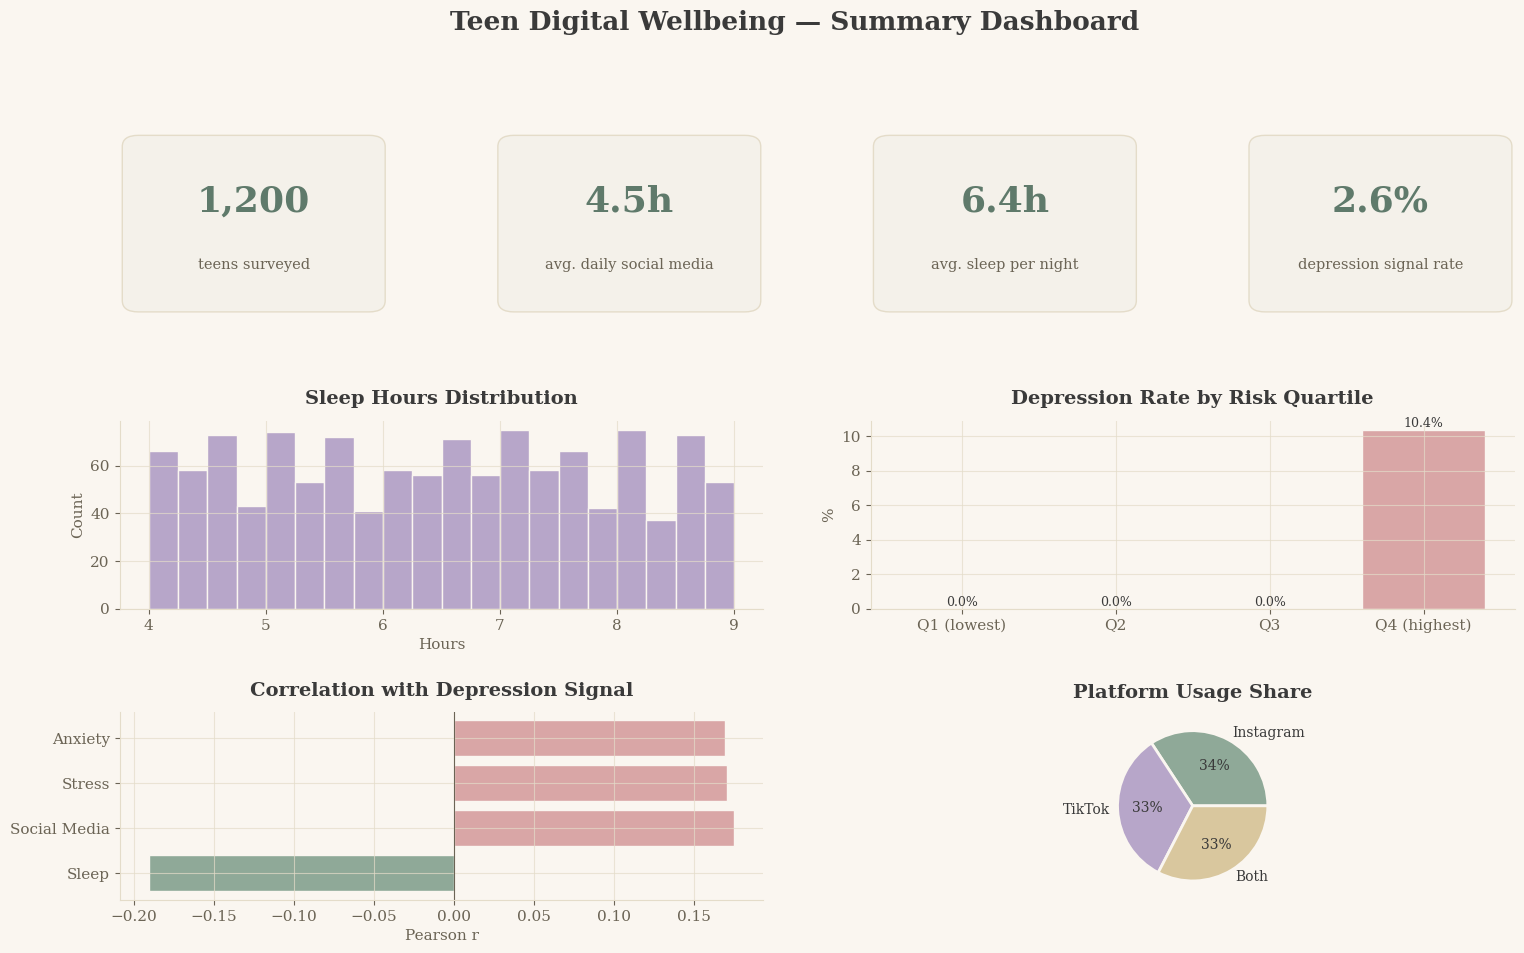

In [13]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.4)

fig.suptitle('Teen Digital Wellbeing — Summary Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0, fontfamily='serif')

# Big stat cards (top row)
stat_cells = [
    (f"{len(df):,}", "teens surveyed"),
    (f"{df['daily_social_media_hours'].mean():.1f}h", "avg. daily social media"),
    (f"{df['sleep_hours'].mean():.1f}h", "avg. sleep per night"),
    (f"{dep_rate:.1f}%", "depression signal rate"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PAPER_DEEP, transform=ax.transAxes))
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=26, color=SAGE_DEEP, fontweight='bold', transform=ax.transAxes, fontfamily='serif')
    ax.text(0.5, 0.28, lab, ha='center', va='center', fontsize=10.5, color=INK_SOFT, transform=ax.transAxes)

# Sleep hist
ax = fig.add_subplot(gs[1, :2])
ax.hist(df['sleep_hours'], bins=20, color=LAVENDER, edgecolor=PAPER)
style_ax(ax, 'Sleep Hours Distribution', 'Hours', 'Count')

# Risk quartile depression rate
ax = fig.add_subplot(gs[1, 2:])
bars = ax.bar(risk_dep.index.astype(str), risk_dep.values, color=[SAGE, GOLD, '#CBAF7A', BLUSH], edgecolor=PAPER)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15, f"{b.get_height():.1f}%", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Depression Rate by Risk Quartile', '', '%')

# Correlation mini bars with depression
ax = fig.add_subplot(gs[2, :2])
top4 = corr['depression_label'].drop('depression_label').reindex(['sleep_hours','daily_social_media_hours','stress_level','anxiety_level'])
bars = ax.barh(['Sleep', 'Social Media', 'Stress', 'Anxiety'], top4.values,
                color=[SAGE if v<0 else BLUSH for v in top4.values], edgecolor=PAPER)
ax.axvline(0, color=INK_SOFT, linewidth=0.8)
style_ax(ax, 'Correlation with Depression Signal', 'Pearson r', '')

# Platform pie
ax = fig.add_subplot(gs[2, 2:])
plat_counts = df['platform_usage'].value_counts()
ax.pie(plat_counts.values, labels=plat_counts.index, colors=[SAGE, LAVENDER, GOLD], autopct='%1.0f%%',
       wedgeprops={'edgecolor':PAPER,'linewidth':2}, textprops={'color':INK, 'fontsize':10})
ax.set_title('Platform Usage Share', color=INK, pad=10)

plt.show()


<h2 id="model" style="font-family:Georgia,serif; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">🤖 12. Predictive Modeling (with an Honest Imbalance Warning)</h2>
<div style="background:#F4F1EA; border-left:3px solid #D9A6A6; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px; margin-bottom:14px;">
<b>Before modeling:</b> the target has only 31 positive cases in 1,200 rows (2.6%). With a test split, that's roughly
6 positive cases in the hold-out set. Any single metric here — especially AUC on a tiny test set — should be read as
illustrative, not as evidence the model would generalize. We use class-weighting rather than oversampling to keep
the exercise transparent, and we report multiple metrics rather than leaning on accuracy alone.
</div>

In [14]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, classification_report, confusion_matrix)

model_df = df.copy()
for c in ['gender', 'platform_usage', 'social_interaction_level']:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['age','gender','daily_social_media_hours','platform_usage','sleep_hours',
            'screen_time_before_sleep','academic_performance','physical_activity',
            'social_interaction_level','stress_level','anxiety_level','addiction_level']
X = model_df[features]
y = model_df['depression_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(f"Train: {X_train.shape[0]} rows ({y_train.sum()} positive)  |  Test: {X_test.shape[0]} rows ({y_test.sum()} positive)")

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=400, max_depth=5, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

models = {'Logistic Regression': (log_reg, X_test_s), 'Random Forest': (rf, X_test)}
results = {}
for name, (m, Xte) in models.items():
    proba = m.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    results[name] = {'proba': proba, 'auc': auc, 'ap': ap}
    print(f"{name}: ROC-AUC = {auc:.3f} | Average Precision = {ap:.3f}")


Train: 900 rows (23 positive)  |  Test: 300 rows (8 positive)
Logistic Regression: ROC-AUC = 0.985 | Average Precision = 0.641
Random Forest: ROC-AUC = 1.000 | Average Precision = 1.000


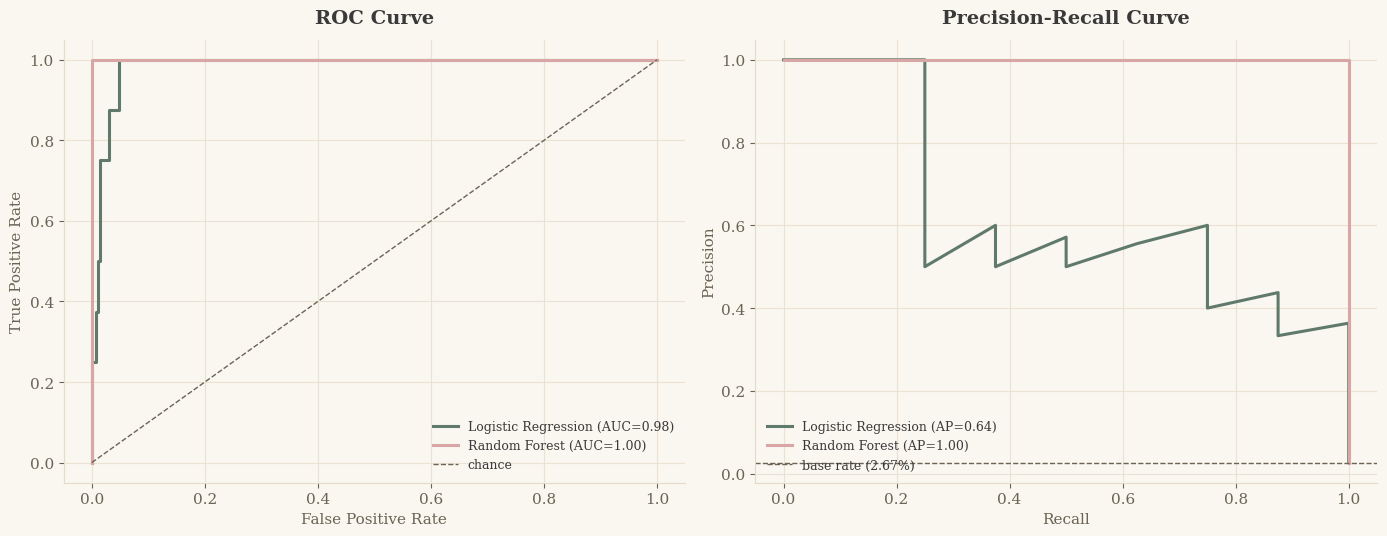

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for (name, res), c in zip(results.items(), [SAGE_DEEP, BLUSH]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=c, linewidth=2.2)
ax.plot([0,1],[0,1], linestyle='--', color=INK_SOFT, linewidth=1, label='chance')
style_ax(ax, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
for (name, res), c in zip(results.items(), [SAGE_DEEP, BLUSH]):
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    ax.plot(rec, prec, label=f"{name} (AP={res['ap']:.2f})", color=c, linewidth=2.2)
base_rate = y_test.mean()
ax.axhline(base_rate, linestyle='--', color=INK_SOFT, linewidth=1, label=f'base rate ({base_rate:.2%})')
style_ax(ax, 'Precision-Recall Curve', 'Recall', 'Precision')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


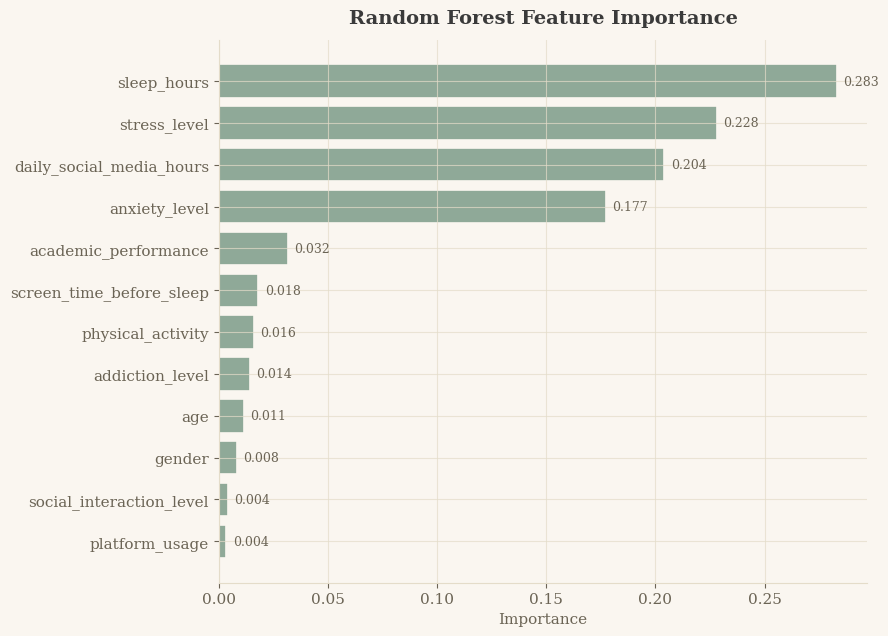


Classification report — Random Forest (threshold=0.5):
                   precision    recall  f1-score   support

        No signal       1.00      1.00      1.00       292
Depression signal       1.00      0.88      0.93         8

         accuracy                           1.00       300
        macro avg       1.00      0.94      0.97       300
     weighted avg       1.00      1.00      1.00       300



In [16]:

importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.barh(importances.index, importances.values, color=SAGE, edgecolor=PAPER, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.003, b.get_y()+b.get_height()/2, f"{b.get_width():.3f}", va='center', fontsize=9, color=INK_SOFT)
style_ax(ax, 'Random Forest Feature Importance', 'Importance', '')
plt.tight_layout()
plt.show()

print("\nClassification report — Random Forest (threshold=0.5):")
print(classification_report(y_test, rf.predict(X_test), target_names=['No signal','Depression signal']))



<div style="background:#F4F1EA; border-left:3px solid #8FA998; padding:14px 20px; font-family:Georgia,serif; color:#4A4438; font-size:14px;">
<b>Reading these results responsibly:</b> both models place sleep, stress, anxiety and social media hours near the
top of feature importance, which matches the correlation and risk-score findings from earlier sections — a
reassuring sign of internal consistency. But with ~6 positive cases in the test set, the AUC and precision-recall
numbers should be treated as a proof-of-concept, not a validated screening tool. A dataset with more positive
examples (or techniques like stratified k-fold CV across the full dataset) would be needed before drawing firm
conclusions.
</div>



<div style="background:linear-gradient(135deg,#F4F1EA 0%,#EDE7DC 100%); padding:36px 38px; border-radius:4px; border:1px solid #D8CFBE; font-family:Georgia,serif; color:#3A3A3A;">

<h2 id="conclusion" style="margin-top:0; font-weight:400; color:#3A3A3A; border-bottom:2px solid #E8E0CF; padding-bottom:8px;">📝 13. Closing Reflections</h2>

<h4 style="color:#6B6455; font-weight:600; margin-bottom:6px;">What held up</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#4A4438;">
<li>Sleep, stress, anxiety and social media hours each show a modest but consistent relationship with the depression signal — weak individually (|r| ≈ 0.17–0.19), but they agree in direction across correlation, group comparison, and feature-importance views.</li>
<li>Stacking those four variables into a simple composite risk score sharpened the signal considerably: the top risk quartile carried essentially all of the depression cases in the dataset.</li>
<li>Most other lifestyle variables — screen time before bed, physical activity, academic performance, addiction level — showed almost no relationship to anything else in the dataset (|r| &lt; 0.06), which is itself a useful (if less exciting) finding.</li>
</ul>

<h4 style="color:#6B6455; font-weight:600; margin-bottom:6px;">What to hold loosely</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#4A4438;">
<li>The depression label is severely imbalanced (31 of 1,200 rows), so sub-group comparisons and model metrics rest on a small number of positive cases.</li>
<li>The dataset's unusually clean structure (zero nulls, zero duplicates) suggests it may be synthetic or heavily pre-processed — a good reason to treat these patterns as hypotheses to test on real-world data, not conclusions in themselves.</li>
</ul>

<div style="height:1px; background:repeating-linear-gradient(90deg,#C9BFA9 0 6px, transparent 6px 12px); margin:20px 0;"></div>

<p style="font-size:13px; color:#8C8574; line-height:1.7; margin-bottom:0;">
This notebook is exploratory and educational — it is not a diagnostic tool and shouldn't be treated as one.
If you or someone you know is struggling, talking to a school counselor, doctor, or trusted adult is always the
right next step.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8C8574; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
